In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
from sklearn import svm
from tensorflow.keras.layers import Dense,BatchNormalization,Dropout,LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras import callbacks
from sklearn.metrics import precision_score,recall_score,confusion_matrix,accuracy_score,f1_score,classification_report

In [5]:
data_df=pd.read_csv("Heart_failure_clinical_records_dataset.csv")

In [6]:
data_df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [7]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [63]:
data_df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

C:\Users\hp\AppData\Local\Temp\ipykernel_6124\1138870773.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x=data_df["DEATH_EVENT"],palette=cols)


[Text(0, 0, '203')]

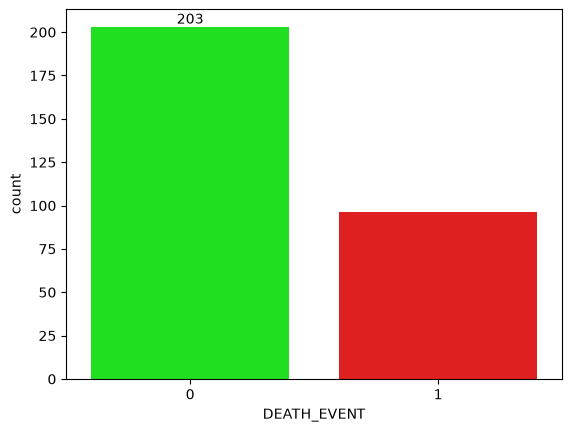

In [8]:
cols=["#00FF00","#FF0000"]
ax=sns.countplot(x=data_df["DEATH_EVENT"],palette=cols)
ax.bar_label(ax.containers[0])

In [9]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.837237,11.900919,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


In [65]:
data_df["DEATH_EVENT"].value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

In [70]:
data_df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


C:\Users\hp\AppData\Local\Temp\ipykernel_6124\2120165358.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_df["DEATH_EVENT"], palette=["green", "red"])


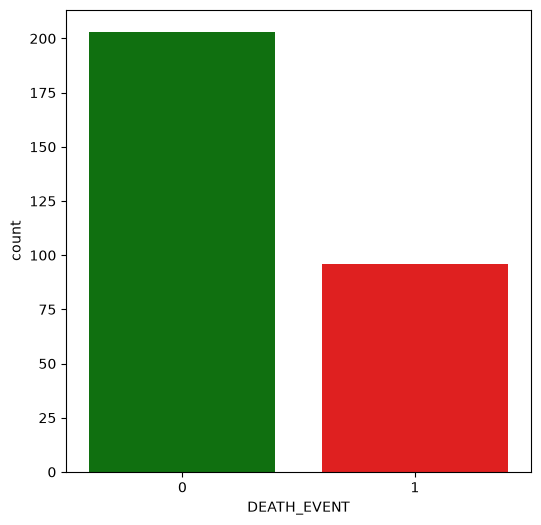

In [71]:
plt.figure(figsize=(6,6))
sns.countplot(x=data_df["DEATH_EVENT"], palette=["green", "red"])
plt.show()

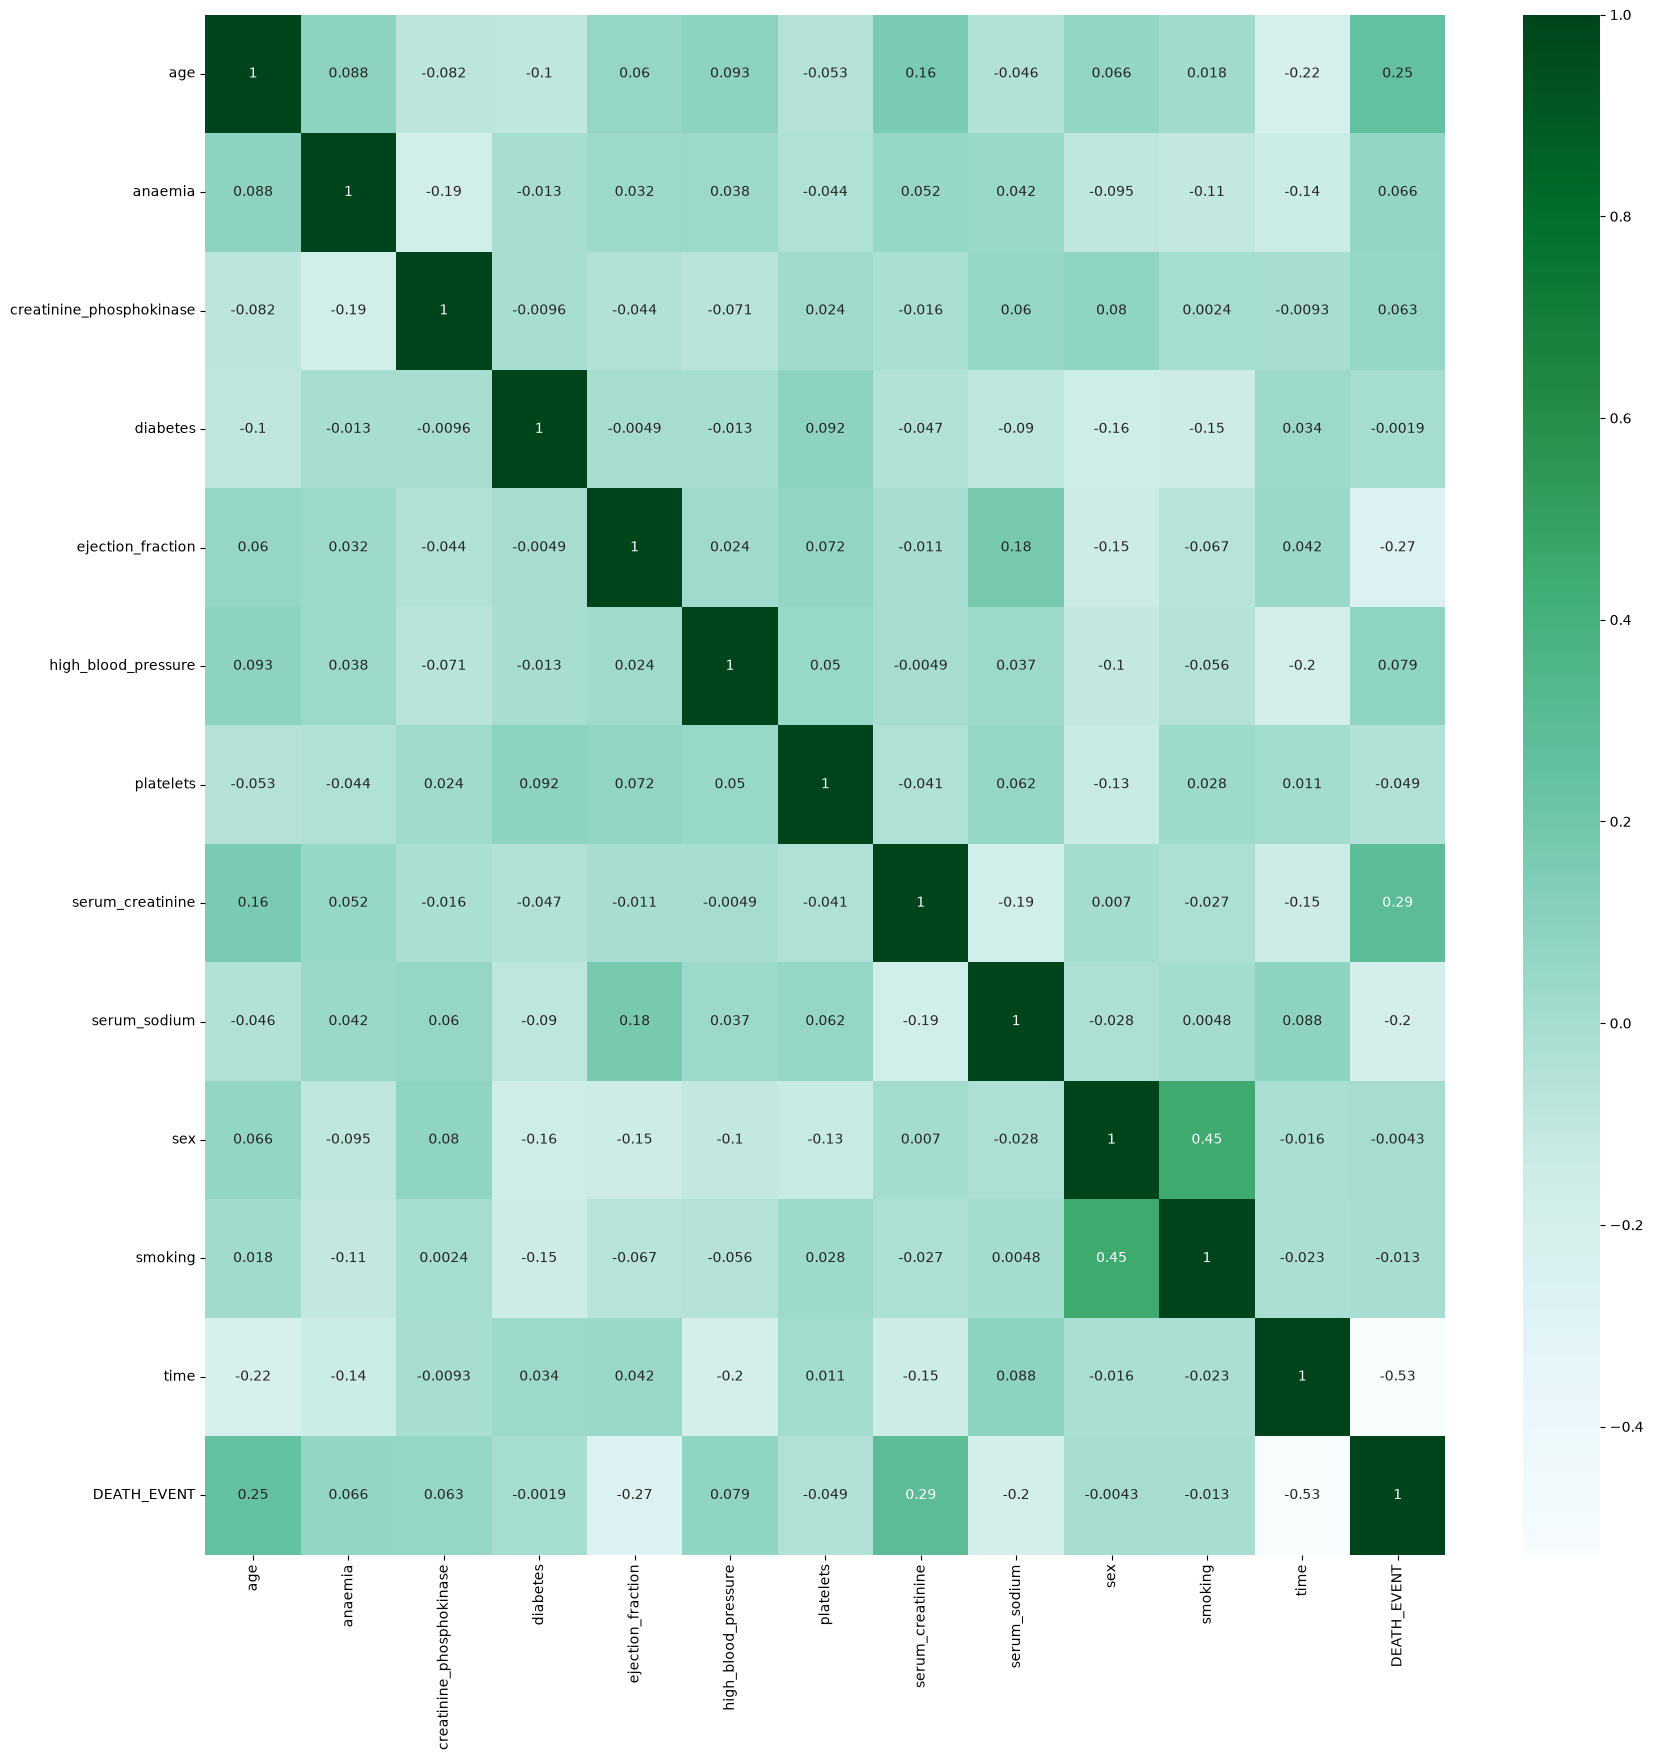

In [12]:
plt.subplots(figsize=(20,20))
sns.heatmap(data_df.corr(),cmap="BuGn",annot=True)
plt.show()

<Axes: >

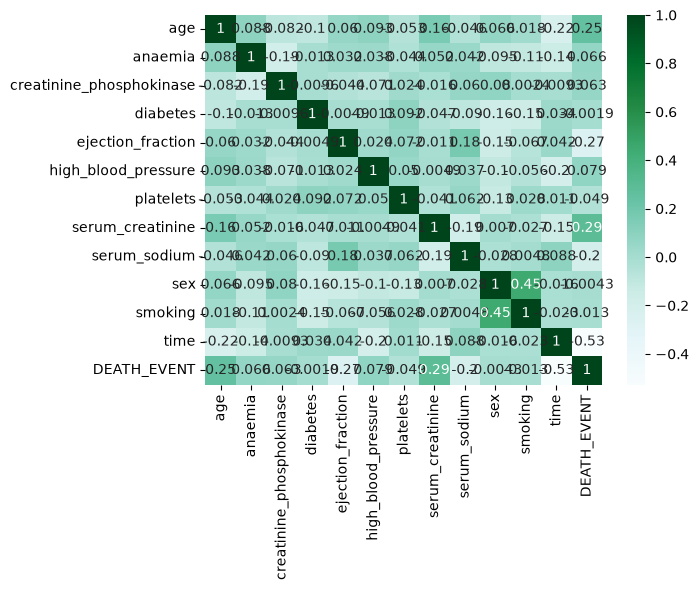

In [13]:
sns.heatmap(data_df.corr(),cmap="BuGn",annot=True)

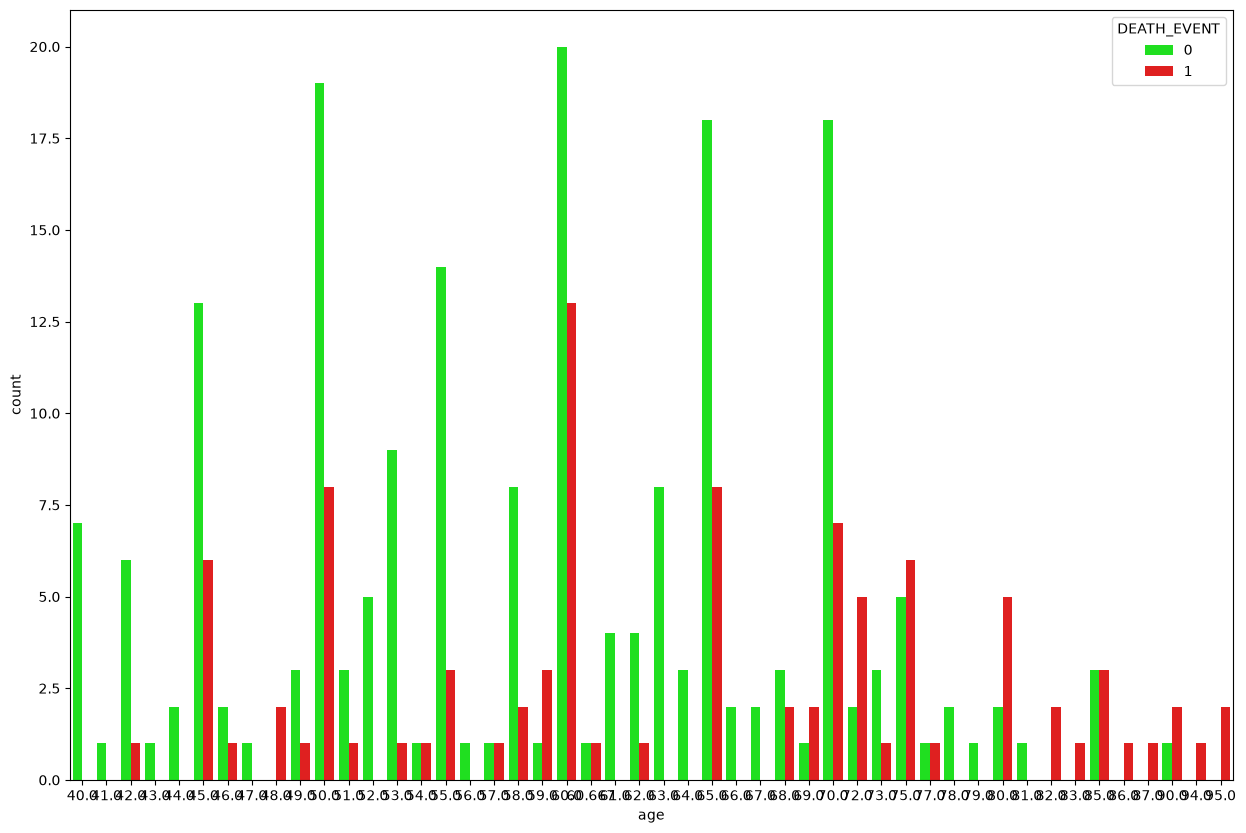

In [16]:
plt.figure(figsize=(15,10))
days_of_week = sns.countplot(
    x=data_df['age'],
    data=data_df,
    hue="DEATH_EVENT",
    palette=cols
)

C:\Users\hp\AppData\Local\Temp\ipykernel_6124\3695450434.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"],y=data_df[i],palette=cols)


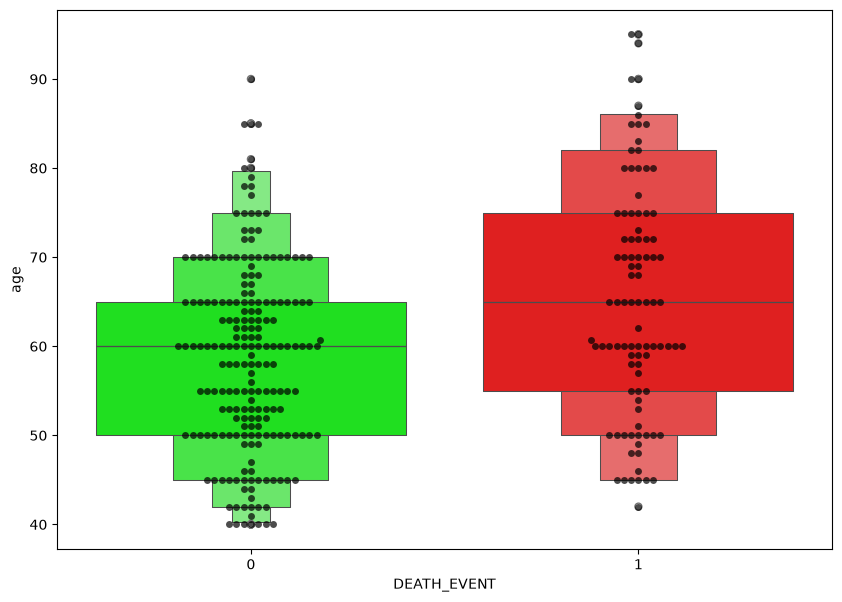

C:\Users\hp\AppData\Local\Temp\ipykernel_6124\3695450434.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"],y=data_df[i],palette=cols)
C:\Users\hp\.conda\envs\ds_project\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


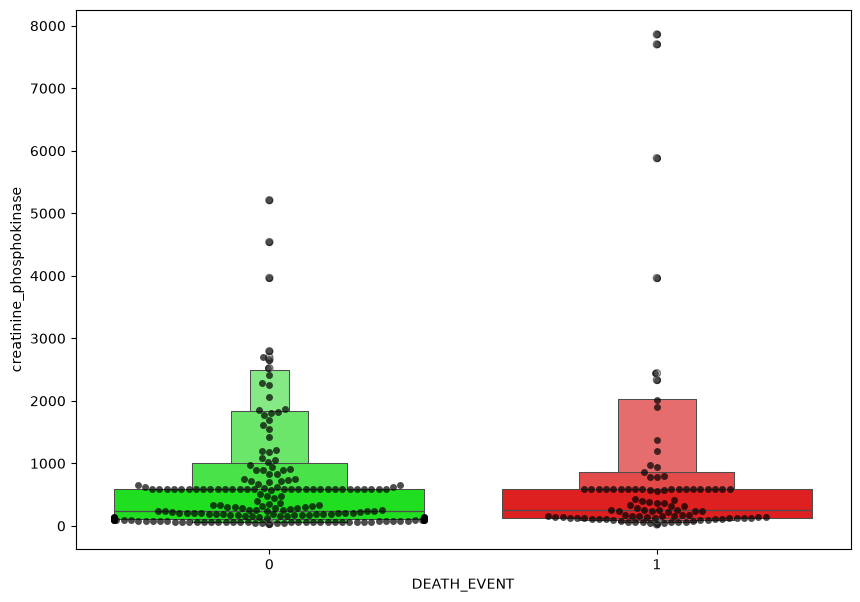

C:\Users\hp\AppData\Local\Temp\ipykernel_6124\3695450434.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"],y=data_df[i],palette=cols)


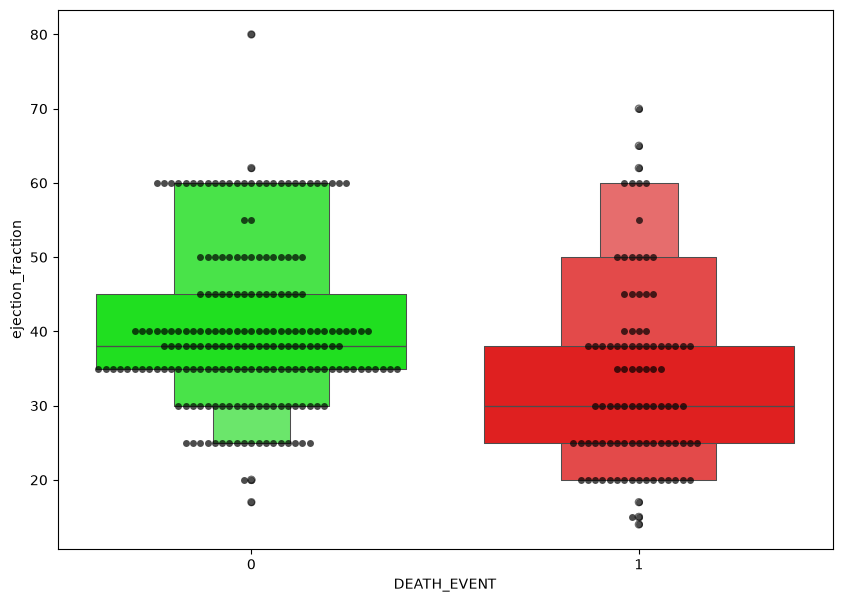

KeyError: 'platlets'

<Figure size 1000x700 with 0 Axes>

In [17]:
feature=["age","creatinine_phosphokinase","ejection_fraction","platlets","serum_creatinine","serum_sodium","time"]
for i in feature:
    plt.figure(figsize=(10,7))
    sns.swarmplot(x=data_df["DEATH_EVENT"],y=data_df[i],color="black",alpha=0.7)
    sns.boxenplot(x=data_df["DEATH_EVENT"],y=data_df[i],palette=cols)
    plt.show()


C:\Users\hp\.conda\envs\ds_project\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\hp\.conda\envs\ds_project\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\hp\.conda\envs\ds_project\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\hp\.conda\envs\ds_project\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\hp\.conda\envs\ds_project\Lib\site-packages\seaborn\categor

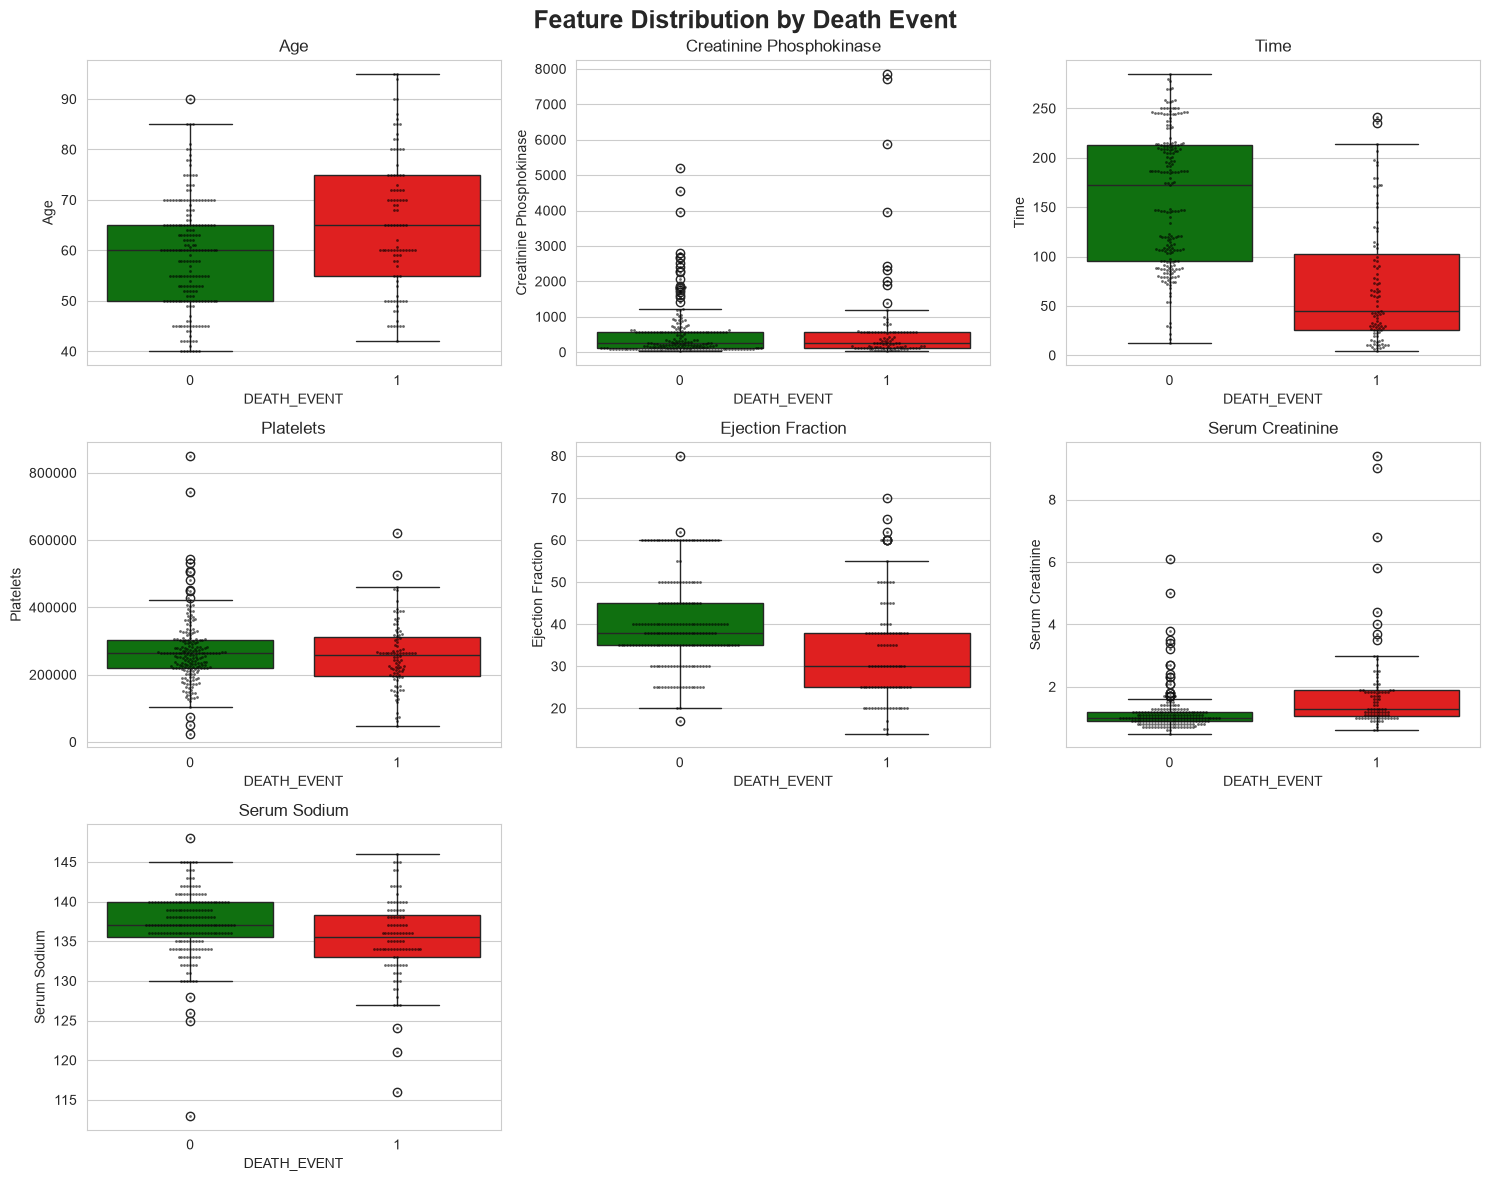

In [72]:
features = [
    "age", "creatinine_phosphokinase", "time", "platelets",
    "ejection_fraction", "serum_creatinine", "serum_sodium"
]

sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):

    sns.boxplot(
        x="DEATH_EVENT",
        y=feature,
        hue="DEATH_EVENT",
        data=data_df,              # or use data if that's your DataFrame name
        palette=["green", "red"],
        legend=False,
        ax=axes[i]
    )

    sns.swarmplot(
        x=data_df["DEATH_EVENT"],
        y=data_df[feature],
        color="black",
        size=2,
        alpha=0.6,
        ax=axes[i]
    )

    axes[i].set_title(
        feature.replace("_", " ").title(),
        fontsize=12
    )

    axes[i].set_xlabel("DEATH_EVENT")
    axes[i].set_ylabel(feature.replace("_", " ").title())

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Feature Distribution by Death Event",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [20]:
x=data_df.drop(["DEATH_EVENT"],axis=1)
y=data_df["DEATH_EVENT"]

In [21]:
col_name=list(x.columns)
s_scaler=preprocessing.StandardScaler()
x_scaled=s_scaler.fit_transform(x)
x_scaled=pd.DataFrame(x_scaled,columns=col_name)

In [22]:
x_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,3.921055e-16,1.001676,-1.753828,-0.827980,-0.070469,0.771211,2.875411
anaemia,299.0,1.009969e-16,1.001676,-0.871105,-0.871105,-0.871105,1.147968,1.147968
creatinine_phosphokinase,299.0,0.000000e+00,1.001676,-0.576918,-0.480393,-0.342574,0.000166,7.514640
diabetes,299.0,9.060014e-17,1.001676,-0.847579,-0.847579,-0.847579,1.179830,1.179830
ejection_fraction,299.0,-3.267546e-17,1.001676,-2.038387,-0.684180,-0.007077,0.585389,3.547716
high_blood_pressure,299.0,0.000000e+00,1.001676,-0.735688,-0.735688,-0.735688,1.359272,1.359272
platelets,299.0,7.723291e-17,1.001676,-2.440155,-0.520870,-0.013908,0.411120,6.008180
serum_creatinine,299.0,1.425838e-16,1.001676,-0.865509,-0.478205,-0.284552,0.005926,7.752020
serum_sodium,299.0,-8.673849e-16,1.001676,-5.363206,-0.595996,0.085034,0.766064,2.582144
sex,299.0,-8.911489e-18,1.001676,-1.359272,-1.359272,0.735688,0.735688,0.735688


<Axes: >

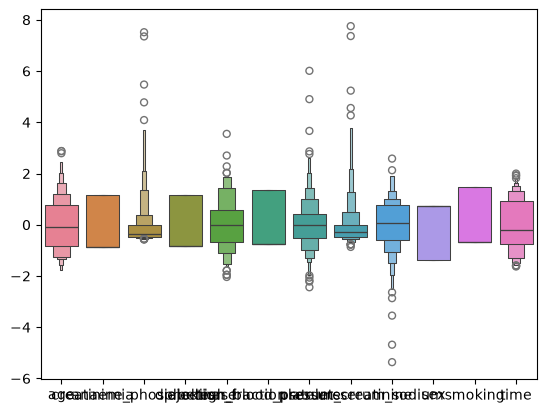

In [23]:
sns.boxenplot(data=x_scaled)

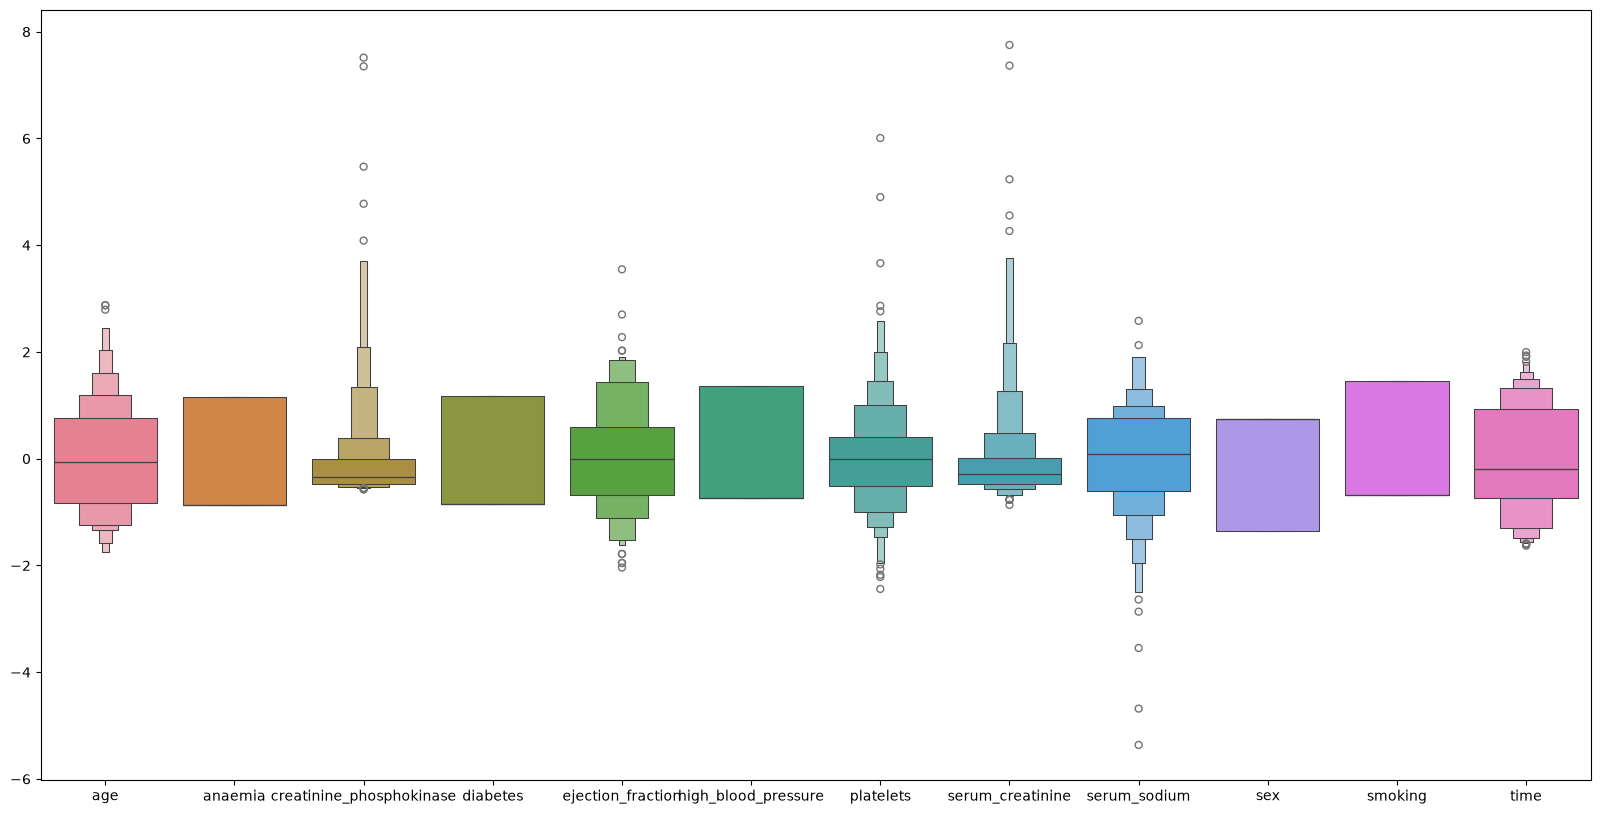

In [24]:
plt.figure(figsize=(20,10))
sns.boxenplot(data=x_scaled)
plt.show()


In [25]:
x_train,x_tests,y_train,y_test=train_test_split(x_scaled,y,test_size=0.3)

In [26]:
model1=svm.SVC()

In [27]:
model1.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [28]:
y_pred=model1.predict(x_tests)

In [29]:
y_pred

array([0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0])

In [30]:
y_test

249    0
109    0
16     1
248    0
102    0
      ..
236    0
168    0
104    0
42     1
242    0
Name: DEATH_EVENT, Length: 90, dtype: int64

In [31]:
y_train

264    0
200    0
137    0
85     0
118    0
      ..
222    0
115    0
194    1
61     1
146    0
Name: DEATH_EVENT, Length: 209, dtype: int64

In [84]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [83]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model1 = SVC()

svc_scores = cross_val_score(
    model1,
    x,
    y,
    cv=kfold,
    scoring="accuracy"
)

model2 = LogisticRegression(max_iter=100)

log_scores = cross_val_score(
    model2,
    x,
    y,
    cv=kfold,
    scoring="accuracy"
)

print("SVC Accuracy:", svc_scores)
print("SVC Max Accuracy:", svc_scores.max())

print("LogisticRegression Accuracy:", log_scores)
print("Logistic Max Accuracy:", log_scores.max())

SVC Accuracy: [0.58333333 0.58333333 0.76666667 0.75       0.71186441]
SVC Max Accuracy: 0.7666666666666667
LogisticRegression Accuracy: [0.8        0.81666667 0.9        0.81666667 0.77966102]
Logistic Max Accuracy: 0.9


C:\Users\hp\.conda\envs\ds_project\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\hp\.conda\envs\ds_project\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing

In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.85        64
           1       0.65      0.58      0.61        26

    accuracy                           0.79        90
   macro avg       0.74      0.73      0.73        90
weighted avg       0.78      0.79      0.78        90



In [86]:
from sklearn import svm
from tensorflow.keras.layers import Dense,BatchNormalization,Dropout,LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras import callbacks
from sklearn.metrics import precision_score,recall_score,confusion_matrix,accuracy_score,f1_score,classification_report

In [34]:
early_stopping = callbacks.EarlyStopping(
    min_delta=0.001,
    patience=20,
    restore_best_weights=True
)

model = Sequential()

model.add(Dense(units=16,
                kernel_initializer='uniform',
                activation='relu',
                input_dim=12))

model.add(Dense(units=8,
                kernel_initializer='uniform',
                activation='relu'))

model.add(Dropout(0.25))

model.add(Dense(units=8,
                kernel_initializer='uniform',
                activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(units=1,
                kernel_initializer='uniform',
                activation='sigmoid'))

C:\Users\hp\.conda\envs\ds_project\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [44]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 425 (1.66 KB)

 Trainable params: 425 (1.66 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = model.fit(
    x_train,
    y_train,
    batch_size=25,
    epochs=100,
    callbacks=[early_stopping],
    validation_split=0.25
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6667 - loss: 0.6928 - val_accuracy: 0.6792 - val_loss: 0.6919
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6603 - loss: 0.6917 - val_accuracy: 0.6792 - val_loss: 0.6909
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6603 - loss: 0.6907 - val_accuracy: 0.6792 - val_loss: 0.6898
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6603 - loss: 0.6897 - val_accuracy: 0.6792 - val_loss: 0.6886
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6603 - loss: 0.6887 - val_accuracy: 0.6792 - val_loss: 0.6874
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6603 - loss: 0.6876 - val_accuracy: 0.6792 - val_loss: 0.6861
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6603 - loss: 0.6865 - val_accuracy: 0.6792 - val_loss: 0.6849
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6603 - loss: 0.6857 - val_accuracy: 0.6792 - val_loss:

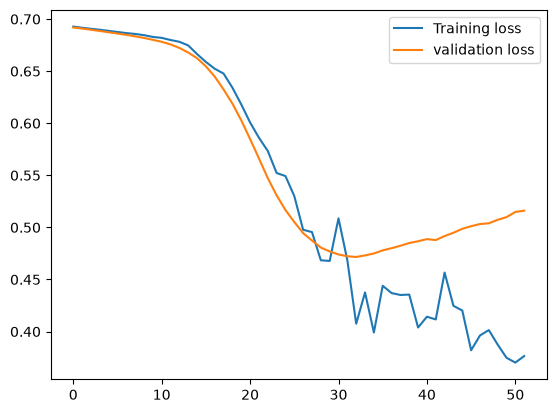

In [53]:
history_df = pd.DataFrame(history.history)

plt.plot(history_df.loc[:, ['accuracy']], label="Training accuracy")
plt.plot(history_df.loc[:, ['val_accuracy']], label="Validation accuracy")

plt.legend()
plt.show()

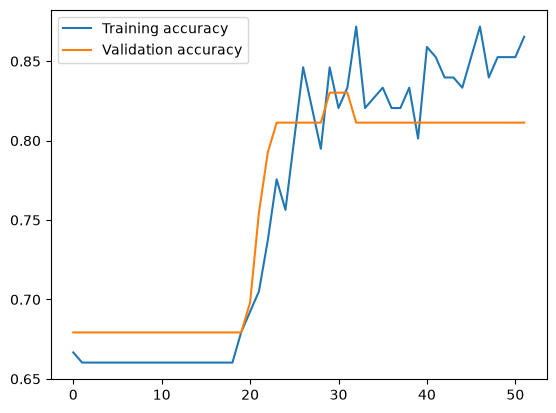

In [59]:
history_df = pd.DataFrame(history.history)

plt.plot(history_df.loc[:, ['accuracy']], label="Training accuracy")
plt.plot(history_df.loc[:, ['val_accuracy']], label="Validation accuracy")

plt.legend()
plt.show()

In [60]:
y_pred = model.predict(x_tests)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [61]:
y_pred = (y_pred > 0.5)

In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.86      0.87        64
           1       0.67      0.69      0.68        26

    accuracy                           0.81        90
   macro avg       0.77      0.78      0.77        90
weighted avg       0.81      0.81      0.81        90

